# 05 - Ablation Study

Notebook này chạy ablation cho mini DiT/action head trên cùng dữ liệu từ notebook 02.

Ba cấu hình tối thiểu theo plan CK:

- `baseline`: LR `1e-4`, 4 layers.
- `lr_low`: LR `5e-5`, 4 layers.
- `shallow`: LR `1e-4`, 2 layers.

Mỗi run train from scratch 1 epoch rồi evaluate trên cùng test split. Output chính là `ablation_summary.csv/json` và `ablation_bar_chart.png`.


In [1]:
import csv
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


In [2]:
SEED = 42
EPOCHS = 1
BATCH_SIZE = 1024
EVAL_BATCH_SIZE = 4096
WEIGHT_DECAY = 1e-4
NUM_HEADS = 4
DROPOUT = 0.1
GRAD_CLIP_NORM = 1.0
USE_AMP = True
NUM_WORKERS = 2
LOG_EVERY = 200
DENOISING_STEPS = 4
STAT_CHUNK_SIZE = 262_144

# None = ablation chính thức trên full train/test split. Đổi sang số nhỏ chỉ khi debug.
MAX_TRAIN_SAMPLES = None
MAX_EVAL_SAMPLES = None
MAX_STEPS_PER_EPOCH = None

ABLATION_RUNS = [
    {'run': 'baseline', 'learning_rate': 1e-4, 'num_layers': 4, 'hidden_dim': 256, 'purpose': 'main configuration'},
    {'run': 'lr_low', 'learning_rate': 5e-5, 'num_layers': 4, 'hidden_dim': 256, 'purpose': 'learning-rate ablation'},
    {'run': 'shallow', 'learning_rate': 1e-4, 'num_layers': 2, 'hidden_dim': 256, 'purpose': 'model-depth ablation'},
]

OUTPUT_ROOT = Path('/kaggle/working/gr00t_ablation_results')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('output:', OUTPUT_ROOT)


device: cuda
output: /kaggle/working/gr00t_ablation_results


In [3]:
def find_prepared_root() -> Path:
    candidates = []
    for base in [Path('/kaggle/input'), Path('/kaggle/working')]:
        if not base.exists():
            continue
        for path in base.rglob('gr00t_prepared_3subsets'):
            if not path.is_dir():
                continue
            required = ['prepare_report.json', 'actions_train.npy', 'states_train.npy', 'actions_test.npy', 'states_test.npy', 'train_samples.parquet', 'test_samples.parquet']
            if all((path / name).exists() for name in required):
                candidates.append(path)
    if not candidates:
        raise FileNotFoundError('Không tìm thấy gr00t_prepared_3subsets. Hãy Add Input output notebook 02.')
    return sorted(candidates, key=lambda p: (0 if str(p).startswith('/kaggle/input') else 1, str(p)))[0]


PREPARED_ROOT = find_prepared_root()
print('PREPARED_ROOT:', PREPARED_ROOT)

with open(PREPARED_ROOT / 'prepare_report.json', 'r', encoding='utf-8') as f:
    prepare_report = json.load(f)

assert prepare_report.get('action_cols') == ['action']
assert prepare_report.get('state_cols') == ['observation.state']
assert prepare_report.get('max_frames_per_episode') is None

print(json.dumps({
    'subsets_found': prepare_report.get('subsets_found'),
    'num_train_samples': prepare_report.get('num_train_samples'),
    'num_test_samples': prepare_report.get('num_test_samples'),
    'action_dim': prepare_report.get('action_dim'),
    'state_dim': prepare_report.get('state_dim'),
}, ensure_ascii=False, indent=2))


PREPARED_ROOT: /kaggle/input/datasets/kimthanh211005/gr00t-prepared-3subsets/gr00t_prepared_3subsets
{
  "subsets_found": [
    "gr1_arms_only.CanSort",
    "gr1_arms_waist.CanToDrawer",
    "gr1_arms_waist.CupToDrawer"
  ],
  "num_train_samples": 4952021,
  "num_test_samples": 1240153,
  "action_dim": 44,
  "state_dim": 44
}


In [4]:
actions_train = np.load(PREPARED_ROOT / 'actions_train.npy', mmap_mode='r')
states_train = np.load(PREPARED_ROOT / 'states_train.npy', mmap_mode='r')
actions_test = np.load(PREPARED_ROOT / 'actions_test.npy', mmap_mode='r')
states_test = np.load(PREPARED_ROOT / 'states_test.npy', mmap_mode='r')
train_samples = pd.read_parquet(PREPARED_ROOT / 'train_samples.parquet')
test_samples = pd.read_parquet(PREPARED_ROOT / 'test_samples.parquet')

assert len(actions_train) == len(states_train) == len(train_samples)
assert len(actions_test) == len(states_test) == len(test_samples)
state_dim = int(states_train.shape[1])
action_dim = int(actions_train.shape[1])
assert state_dim == int(states_test.shape[1])
assert action_dim == int(actions_test.shape[1])

print('train:', states_train.shape, actions_train.shape)
print('test:', states_test.shape, actions_test.shape)
print('train subset counts:')
print(train_samples['__subset'].value_counts())
print('test subset counts:')
print(test_samples['__subset'].value_counts())


def compute_mean_std(arr: np.ndarray, chunk_size: int = STAT_CHUNK_SIZE):
    total = np.zeros(arr.shape[1], dtype=np.float64)
    total_sq = np.zeros(arr.shape[1], dtype=np.float64)
    n = 0
    for start in tqdm(range(0, len(arr), chunk_size), desc='Computing stats'):
        chunk = np.asarray(arr[start:start + chunk_size], dtype=np.float32)
        total += chunk.sum(axis=0, dtype=np.float64)
        total_sq += np.square(chunk, dtype=np.float64).sum(axis=0, dtype=np.float64)
        n += len(chunk)
    mean = total / max(n, 1)
    var = np.maximum(total_sq / max(n, 1) - mean ** 2, 1e-8)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)


state_mean, state_std = compute_mean_std(states_train)
action_mean, action_std = compute_mean_std(actions_train)
print('state std min/max:', float(state_std.min()), float(state_std.max()))
print('action std min/max:', float(action_std.min()), float(action_std.max()))


train: (4952021, 44) (4952021, 44)
test: (1240153, 44) (1240153, 44)
train subset counts:
__subset
gr1_arms_waist.CanToDrawer    2559306
gr1_arms_waist.CupToDrawer    2128952
gr1_arms_only.CanSort          263763
Name: count, dtype: int64
test subset counts:
__subset
gr1_arms_waist.CanToDrawer    651120
gr1_arms_waist.CupToDrawer    535918
gr1_arms_only.CanSort          53115
Name: count, dtype: int64


Computing stats:   0%|          | 0/19 [00:00<?, ?it/s]

Computing stats:   0%|          | 0/19 [00:00<?, ?it/s]

state std min/max: 9.999999747378752e-05 0.5694786310195923
action std min/max: 9.999999747378752e-05 2.715195655822754


In [5]:
class StateActionDataset(Dataset):
    def __init__(self, states, actions, state_mean, state_std, action_mean, action_std):
        self.states = states
        self.actions = actions
        self.state_mean = state_mean
        self.state_std = state_std
        self.action_mean = action_mean
        self.action_std = action_std

    def __len__(self):
        return len(self.actions)

    def __getitem__(self, idx):
        state = np.asarray(self.states[idx], dtype=np.float32)
        action = np.asarray(self.actions[idx], dtype=np.float32)
        state = (state - self.state_mean) / self.state_std
        action = (action - self.action_mean) / self.action_std
        return int(idx), torch.from_numpy(state), torch.from_numpy(action)


train_base = StateActionDataset(states_train, actions_train, state_mean, state_std, action_mean, action_std)
test_base = StateActionDataset(states_test, actions_test, state_mean, state_std, action_mean, action_std)

if MAX_TRAIN_SAMPLES is not None and MAX_TRAIN_SAMPLES < len(train_base):
    rng = np.random.default_rng(SEED)
    train_indices = rng.choice(len(train_base), size=int(MAX_TRAIN_SAMPLES), replace=False)
    train_dataset = Subset(train_base, train_indices.tolist())
else:
    train_dataset = train_base

if MAX_EVAL_SAMPLES is not None and MAX_EVAL_SAMPLES < len(test_base):
    rng = np.random.default_rng(SEED)
    eval_indices = np.sort(rng.choice(len(test_base), size=int(MAX_EVAL_SAMPLES), replace=False))
    eval_dataset = Subset(test_base, eval_indices.tolist())
else:
    eval_dataset = test_base

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(), drop_last=True)
eval_loader = DataLoader(eval_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('train samples:', len(train_dataset), 'batches:', len(train_loader))
print('eval samples:', len(eval_dataset), 'batches:', len(eval_loader))


train samples: 4952021 batches: 4835
eval samples: 1240153 batches: 303


In [6]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device, dtype=t.dtype) / max(half - 1, 1))
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class MiniDiTActionHead(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int, num_layers: int, num_heads: int, dropout: float):
        super().__init__()
        self.action_proj = nn.Linear(action_dim, hidden_dim)
        self.state_proj = nn.Linear(state_dim, hidden_dim)
        self.time_embed = nn.Sequential(SinusoidalTimeEmbedding(hidden_dim), nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Linear(hidden_dim, hidden_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(hidden_dim)
        self.out = nn.Linear(hidden_dim, action_dim)

    def forward(self, noisy_action: torch.Tensor, state: torch.Tensor, tau: torch.Tensor) -> torch.Tensor:
        time = self.time_embed(tau)
        action_token = self.action_proj(noisy_action) + time
        state_token = self.state_proj(state) + time
        tokens = torch.stack([action_token, state_token], dim=1)
        tokens = self.blocks(tokens)
        return self.out(self.norm(tokens[:, 0]))


def make_model(run_cfg):
    return MiniDiTActionHead(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=int(run_cfg['hidden_dim']),
        num_layers=int(run_cfg['num_layers']),
        num_heads=NUM_HEADS,
        dropout=DROPOUT,
    ).to(device)


In [7]:
state_mean_t = torch.from_numpy(state_mean).to(device)
state_std_t = torch.from_numpy(state_std).to(device)
action_mean_t = torch.from_numpy(action_mean).to(device)
action_std_t = torch.from_numpy(action_std).to(device)


def train_one_run(run_cfg):
    run_name = run_cfg['run']
    run_dir = OUTPUT_ROOT / f'run_{run_name}'
    run_dir.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    model = make_model(run_cfg)
    optimizer = torch.optim.AdamW(model.parameters(), lr=float(run_cfg['learning_rate']), weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and torch.cuda.is_available())
    num_params = sum(p.numel() for p in model.parameters())
    log_rows = []
    global_step = 0
    start_time = time.time()
    model.train()

    for epoch in range(1, EPOCHS + 1):
        losses = []
        max_steps = len(train_loader) if MAX_STEPS_PER_EPOCH is None else min(int(MAX_STEPS_PER_EPOCH), len(train_loader))
        pbar = tqdm(train_loader, total=max_steps, desc=f'{run_name} epoch {epoch}/{EPOCHS}')
        for step, (_, state, action) in enumerate(pbar, start=1):
            if step > max_steps:
                break
            state = state.to(device, non_blocking=True)
            action = action.to(device, non_blocking=True)
            tau = torch.rand(action.size(0), device=device)
            noise = torch.randn_like(action)
            noisy_action = tau[:, None] * action + (1.0 - tau[:, None]) * noise
            target_vector_field = noise - action
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):
                pred = model(noisy_action, state, tau)
                loss = F.mse_loss(pred, target_vector_field)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            global_step += 1
            loss_value = float(loss.detach().cpu())
            losses.append(loss_value)
            if step == 1 or step % LOG_EVERY == 0 or step == max_steps:
                log_rows.append({'run': run_name, 'epoch': epoch, 'step': step, 'global_step': global_step, 'loss': loss_value, 'grad_norm': float(grad_norm.detach().cpu()), 'elapsed_sec': round(time.time() - start_time, 2)})
                pbar.set_postfix(loss=f'{loss_value:.5f}')
        print(run_name, 'epoch mean loss:', float(np.mean(losses)))

    pd.DataFrame(log_rows).to_csv(run_dir / 'train_log.csv', index=False)
    config = {**run_cfg, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'num_heads': NUM_HEADS, 'dropout': DROPOUT, 'state_dim': state_dim, 'action_dim': action_dim, 'num_params': int(num_params), 'train_samples': int(len(train_dataset)), 'full_epoch_completed': MAX_TRAIN_SAMPLES is None and MAX_STEPS_PER_EPOCH is None}
    with open(run_dir / 'config.json', 'w', encoding='utf-8') as f:
        json.dump(config, f, ensure_ascii=False, indent=2)
    torch.save({'model_state_dict': model.state_dict(), 'config': config, 'normalization': {'state_mean': state_mean, 'state_std': state_std, 'action_mean': action_mean, 'action_std': action_std}, 'global_step': global_step}, run_dir / 'checkpoint_last.pt')
    return model, {'run': run_name, 'global_steps': global_step, 'train_last_loss': float(log_rows[-1]['loss']), 'train_elapsed_sec': round(time.time() - start_time, 2), 'num_params': int(num_params), 'run_dir': str(run_dir)}


In [8]:
@torch.no_grad()
def sample_actions(model, state_norm: torch.Tensor, steps: int) -> torch.Tensor:
    pred = torch.randn(state_norm.size(0), action_dim, device=state_norm.device)
    dt = 1.0 / steps
    for step in range(steps):
        tau = torch.full((state_norm.size(0),), step / steps, device=state_norm.device)
        vector_field = model(pred, state_norm, tau)
        pred = pred - dt * vector_field
    return pred


def finalize_bucket(bucket):
    mse = bucket['sq_sum'] / max(bucket['count'], 1)
    mae = bucket['abs_sum'] / max(bucket['count'], 1)
    return {'samples': int(bucket['samples']), 'mse': float(mse), 'mae': float(mae), 'rmse': float(math.sqrt(mse))}


def evaluate_one_run(model, run_cfg):
    run_name = run_cfg['run']
    run_dir = OUTPUT_ROOT / f'run_{run_name}'
    model.eval()
    overall = {'sq_sum': 0.0, 'abs_sum': 0.0, 'count': 0, 'samples': 0}
    per_subset = {}
    flow_loss_sum = 0.0
    flow_batches = 0
    torch.manual_seed(SEED)
    start_time = time.time()
    for idx, state, action in tqdm(eval_loader, desc=f'eval {run_name}'):
        idx_np = idx.numpy()
        state = state.to(device, non_blocking=True)
        action = action.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):
            tau = torch.rand(action.size(0), device=device)
            noise = torch.randn_like(action)
            noisy = tau[:, None] * action + (1.0 - tau[:, None]) * noise
            flow_target = noise - action
            flow_pred = model(noisy, state, tau)
            flow_loss = F.mse_loss(flow_pred, flow_target)
            pred_norm = sample_actions(model, state, DENOISING_STEPS)
        pred = pred_norm.float() * action_std_t + action_mean_t
        target = action.float() * action_std_t + action_mean_t
        diff = pred - target
        sq = diff.square().detach().cpu().numpy()
        ab = diff.abs().detach().cpu().numpy()
        overall['sq_sum'] += float(sq.sum())
        overall['abs_sum'] += float(ab.sum())
        overall['count'] += int(sq.size)
        overall['samples'] += int(sq.shape[0])
        flow_loss_sum += float(flow_loss.detach().cpu())
        flow_batches += 1
        subset_values = test_samples.iloc[idx_np]['__subset'].to_numpy()
        for subset in np.unique(subset_values):
            mask = subset_values == subset
            bucket = per_subset.setdefault(str(subset), {'sq_sum': 0.0, 'abs_sum': 0.0, 'count': 0, 'samples': 0})
            bucket['sq_sum'] += float(sq[mask].sum())
            bucket['abs_sum'] += float(ab[mask].sum())
            bucket['count'] += int(sq[mask].size)
            bucket['samples'] += int(mask.sum())
    metrics = finalize_bucket(overall)
    metrics['flow_matching_test_loss'] = flow_loss_sum / max(flow_batches, 1)
    metrics['eval_elapsed_sec'] = round(time.time() - start_time, 2)
    subset_rows = [{'run': run_name, 'subset': subset, **finalize_bucket(bucket)} for subset, bucket in sorted(per_subset.items())]
    pd.DataFrame(subset_rows).to_csv(run_dir / 'per_subset_metrics.csv', index=False)
    with open(run_dir / 'eval_summary.json', 'w', encoding='utf-8') as f:
        json.dump({'run': run_name, 'metrics': metrics, 'per_subset_metrics': subset_rows}, f, ensure_ascii=False, indent=2)
    return metrics, subset_rows


In [9]:
summary_rows = []
all_subset_rows = []
for run_cfg in ABLATION_RUNS:
    print('\n' + '=' * 90)
    print('Running ablation:', run_cfg)
    model, train_info = train_one_run(run_cfg)
    metrics, subset_rows = evaluate_one_run(model, run_cfg)
    row = {
        'run': run_cfg['run'],
        'purpose': run_cfg['purpose'],
        'learning_rate': run_cfg['learning_rate'],
        'num_layers': run_cfg['num_layers'],
        'hidden_dim': run_cfg['hidden_dim'],
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'global_steps': train_info['global_steps'],
        'num_params': train_info['num_params'],
        'train_last_loss': train_info['train_last_loss'],
        'test_mse': metrics['mse'],
        'test_mae': metrics['mae'],
        'test_rmse': metrics['rmse'],
        'flow_matching_test_loss': metrics['flow_matching_test_loss'],
        'train_elapsed_sec': train_info['train_elapsed_sec'],
        'eval_elapsed_sec': metrics['eval_elapsed_sec'],
        'run_dir': train_info['run_dir'],
    }
    summary_rows.append(row)
    all_subset_rows.extend(subset_rows)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ablation_df = pd.DataFrame(summary_rows).sort_values('test_mse').reset_index(drop=True)
subset_df = pd.DataFrame(all_subset_rows)
ablation_df.to_csv(OUTPUT_ROOT / 'ablation_summary.csv', index=False)
subset_df.to_csv(OUTPUT_ROOT / 'ablation_per_subset_metrics.csv', index=False)

display(ablation_df)



Running ablation: {'run': 'baseline', 'learning_rate': 0.0001, 'num_layers': 4, 'hidden_dim': 256, 'purpose': 'main configuration'}


/tmp/ipykernel_23/4069930490.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/ipykernel_23/3491721397.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and torch.cuda.is_available())


baseline epoch 1/1:   0%|          | 0/4835 [00:00<?, ?it/s]

/tmp/ipykernel_23/3491721397.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):


baseline epoch mean loss: 0.1761414407805425


...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f07828fd6c0><function _MultiProcessingDataLoaderIter.__del__ at 0x7f07828fd6c0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()
self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
if w.is_alive():    
if w.is_alive():
              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

shallow epoch mean loss: 0.1878837676505022


eval shallow:   0%|          | 0/303 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f07828fd6c0><function _MultiProcessingDataLoaderIter.__del__ at 0x7f07828fd6c0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()    
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
        if w.is_alive():if w.is_alive():

              ^^^^^^^^^^^^^^^^^^^^^^^
^Exception ignored in:   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

<function _MultiProcessingDataLoaderIter.__del__ at 0x7f07828fd6c0>      File

,run,purpose,learning_rate,num_layers,hidden_dim,batch_size,epochs,global_steps,num_params,train_last_loss,test_mse,test_mae,test_rmse,flow_matching_test_loss,train_elapsed_sec,eval_elapsed_sec,run_dir
0,baseline,main configuration,0.00010,4,256,1024,1,4835,3325484,0.118771,0.021758,0.023373,0.147507,0.079416,100.77,23.74,/kaggle/working/gr00t_ablation_results/run_bas...
1,lr_low,learning-rate ablation,0.00005,4,256,1024,1,4835,3325484,0.139148,0.024912,0.029210,0.157837,0.090920,99.43,23.27,/kaggle/working/gr00t_ablation_results/run_lr_low
2,shallow,model-depth ablation,0.00010,2,256,1024,1,4835,1745964,0.124804,0.024961,0.025724,0.157991,0.083961,73.92,16.74,/kaggle/working/gr00t_ablation_results/run_sha...


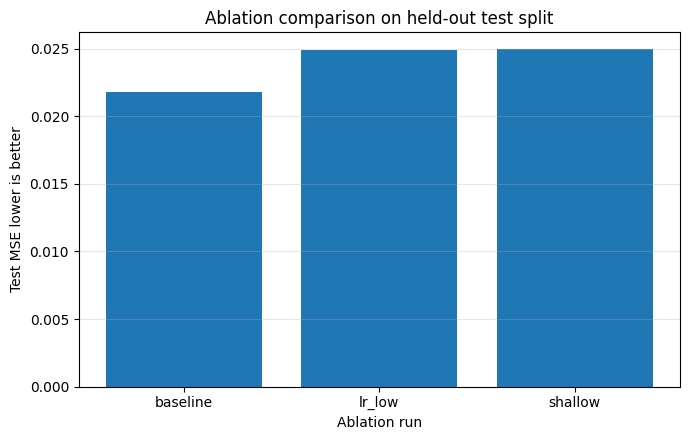

{
  "best_run_by_mse": "baseline",
  "best_mse": 0.021758461503123223,
  "num_runs": 3,
  "full_train_epoch_per_run": true,
  "eval_full_test_split": true
}
Saved artifacts:
- ablation_bar_chart.png 0.035 MB
- ablation_per_subset_metrics.csv 0.001 MB
- ablation_summary.csv 0.001 MB
- ablation_summary.json 0.009 MB
- run_baseline/
- run_lr_low/
- run_shallow/


In [10]:
plt.figure(figsize=(7, 4.5))
plt.bar(ablation_df['run'], ablation_df['test_mse'])
plt.ylabel('Test MSE lower is better')
plt.xlabel('Ablation run')
plt.title('Ablation comparison on held-out test split')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'ablation_bar_chart.png', dpi=160)
plt.show()

ablation_summary = {
    'status': 'completed',
    'objective': 'Ablation study for mini DiT/action head.',
    'prepared_root': str(PREPARED_ROOT),
    'output_root': str(OUTPUT_ROOT),
    'max_train_samples': MAX_TRAIN_SAMPLES,
    'max_eval_samples': MAX_EVAL_SAMPLES,
    'max_steps_per_epoch': MAX_STEPS_PER_EPOCH,
    'full_train_epoch_per_run': MAX_TRAIN_SAMPLES is None and MAX_STEPS_PER_EPOCH is None,
    'eval_full_test_split': MAX_EVAL_SAMPLES is None,
    'denoising_steps': DENOISING_STEPS,
    'runs': ablation_df.to_dict(orient='records'),
    'per_subset_metrics': subset_df.to_dict(orient='records'),
    'best_run_by_mse': ablation_df.iloc[0].to_dict(),
    'prepare_report': prepare_report,
    'artifacts': [
        'ablation_summary.csv',
        'ablation_summary.json',
        'ablation_bar_chart.png',
        'ablation_per_subset_metrics.csv',
        'run_baseline/',
        'run_lr_low/',
        'run_shallow/',
    ],
}

with open(OUTPUT_ROOT / 'ablation_summary.json', 'w', encoding='utf-8') as f:
    json.dump(ablation_summary, f, ensure_ascii=False, indent=2)

print(json.dumps({
    'best_run_by_mse': ablation_summary['best_run_by_mse']['run'],
    'best_mse': ablation_summary['best_run_by_mse']['test_mse'],
    'num_runs': len(ablation_df),
    'full_train_epoch_per_run': ablation_summary['full_train_epoch_per_run'],
    'eval_full_test_split': ablation_summary['eval_full_test_split'],
}, indent=2))
print('Saved artifacts:')
for path in sorted(OUTPUT_ROOT.iterdir()):
    if path.is_dir():
        print('-', path.name + '/')
    else:
        print('-', path.name, round(path.stat().st_size / (1024 ** 2), 3), 'MB')


## Sau Khi Chạy Xong

Kiểm tra tab Output có thư mục:

```text
gr00t_ablation_results/
  ablation_summary.csv
  ablation_summary.json
  ablation_bar_chart.png
  ablation_per_subset_metrics.csv
  run_baseline/
  run_lr_low/
  run_shallow/
```

Bảng quan trọng cho slide là `ablation_summary.csv`: Run, LR, Layers, Hidden dim, Test MSE, Test MAE, nhận xét.
